# **Actividad Fundamental 6**
### ***Aprendizaje Supervisado, Árbol de Decisión***
Integrantes

Levi Abdiel Tiburcio Sánchez - 2178165 - N5

Julio César Ramírez Martínez - 2094921 - N5

Andrés Fernando Montes Aguilar - 2097799 - N5

Manuel Sebastián Garza Garza - 2096889 - N5

Juan Ángel Salazar Yáñez - 2120777 - N5

In [17]:
#Carga de Librerías
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn import tree
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import seaborn as sns
import numpy as np

In [18]:
#Carga de Datos
brstcan = load_breast_cancer()
x = brstcan.data
y = brstcan.target
print ("Etiquetas")
print (brstcan.target_names)
print ("Atributos")
print (brstcan.feature_names)

Etiquetas
['malignant' 'benign']
Atributos
['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness' 'mean compactness' 'mean concavity'
 'mean concave points' 'mean symmetry' 'mean fractal dimension'
 'radius error' 'texture error' 'perimeter error' 'area error'
 'smoothness error' 'compactness error' 'concavity error'
 'concave points error' 'symmetry error' 'fractal dimension error'
 'worst radius' 'worst texture' 'worst perimeter' 'worst area'
 'worst smoothness' 'worst compactness' 'worst concavity'
 'worst concave points' 'worst symmetry' 'worst fractal dimension']


In [19]:
#Procesamiento de Datos
xtrain, xtest, ytrain, ytest = train_test_split(x, y, test_size=.2, random_state=7)


In [20]:
#Entrenamiento del modelo
arbol= DecisionTreeClassifier()
arbol.fit(xtrain, ytrain)

DecisionTreeClassifier()

In [21]:
trainacc=arbol.score(xtrain, ytrain)
print(trainacc)

1.0


In [22]:
#Prueba de Modelo
predy= arbol.predict(xtest)

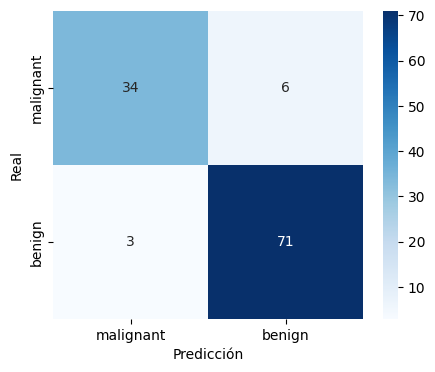

In [23]:
#Obtenemos matriz de confusión
matcon= confusion_matrix(ytest, predy)
plt.figure(figsize=(5,4))
sns.heatmap(matcon, annot=True, fmt="d", cmap="Blues", xticklabels= brstcan.target_names, yticklabels= brstcan.target_names)
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.show()

In [24]:
#Comparamos valores de predicción con los de testeo
#Prueba 1
print(predy[7])
print(ytest[7])
print("")
#Prueba 2
print(predy[-7])
print(ytest[-7])

1
1

1
1


In [25]:
#Obtenemos la precisión del modelo
prec= accuracy_score(ytest, predy)
print("Precisión:", prec)
print("Clasificaciones:\n",classification_report(ytest, predy, target_names=brstcan.target_names))

Precisión: 0.9210526315789473
Clasificaciones:
               precision    recall  f1-score   support

   malignant       0.92      0.85      0.88        40
      benign       0.92      0.96      0.94        74

    accuracy                           0.92       114
   macro avg       0.92      0.90      0.91       114
weighted avg       0.92      0.92      0.92       114



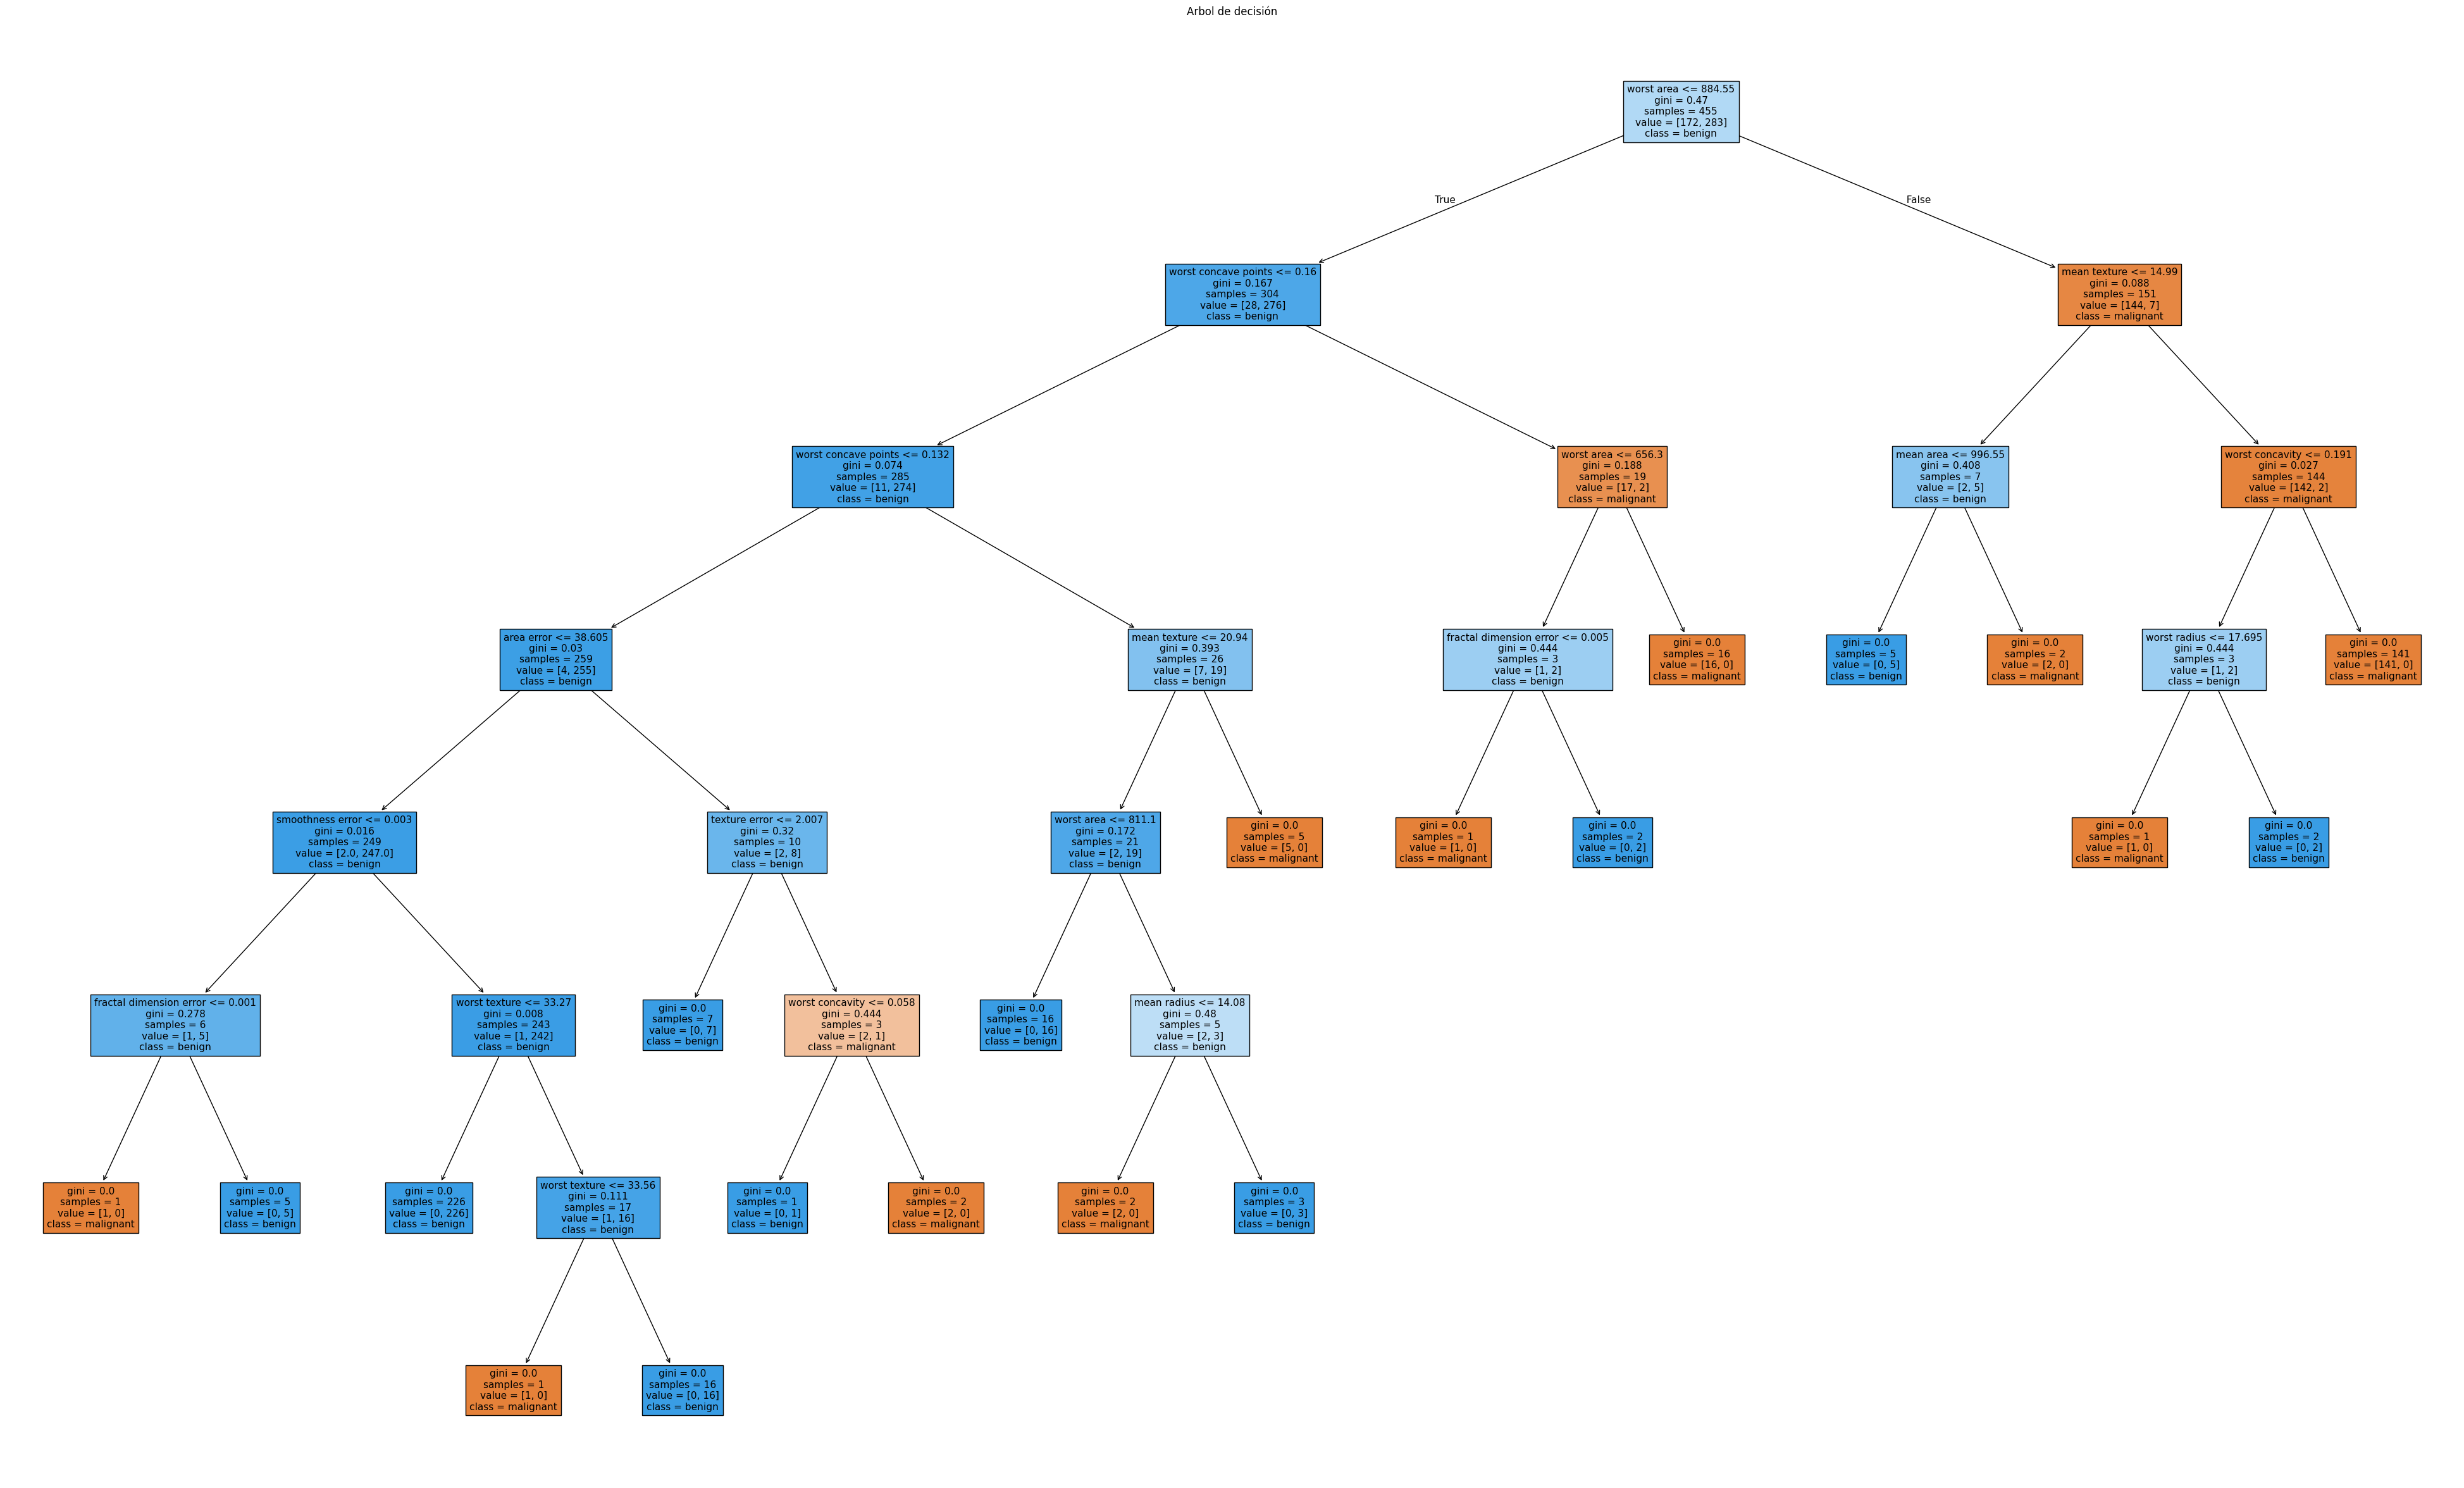

In [16]:
#Visualizacion del arbol de decision
plt.figure(figsize=(50,30))
tree.plot_tree(arbol, filled=True, feature_names=brstcan.feature_names, class_names=brstcan.target_names)
plt.title("Arbol de decisión")
plt.savefig("decision_tree.png", dpi=300)
plt.show()